# Credit Card Default Prediction
**Dataset:** Default of Credit Card Clients — UCI Machine Learning Repository  
**Citation:** Yeh, I-Cheng. (2016). UCI Machine Learning Repository. [online] archive.ics.uci.edu. Available at: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.  
**Author:** Aljoharah Alrajhi 
**Date:** 2/2/2026

## Step 1 — Problem Framing

**Prediction type:** Binary classification  
**Target:** `DEFAULT` — 1 if the client defaulted next month, 0 otherwise  
**Primary metric:** ROC-AUC  
**Secondary metric:** PR-AUC (Precision-Recall)  
**Baseline:** Dummy classifier predicting the majority class

In [54]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded.')

Libraries loaded.


In [55]:
df = pd.read_csv('default of credit card clients.csv', header=1)

df = df.rename(columns={'default payment next month': 'DEFAULT'})
df = df.drop(columns=['ID'])

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 30,000
Columns: 24


In [56]:
print('=== Missing values ===')
print(df.isnull().sum())

print('\n=== Target distribution ===')
vc = df['DEFAULT'].value_counts()
print(vc)
print(f'\nDefault rate: {vc[1] / len(df) * 100:.1f}%')

=== Missing values ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

=== Target distribution ===
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.1%


In [57]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Step 2 — Exploratory Data Analysis (EDA)

### 2.1 Class Imbalance

The target variable is imbalanced — roughly 78% non-default vs 22% default.
This is important because a model that always predicts "no default" would still
be 78% accurate, which is misleading. This is why we use ROC-AUC and PR-AUC
instead of raw accuracy.

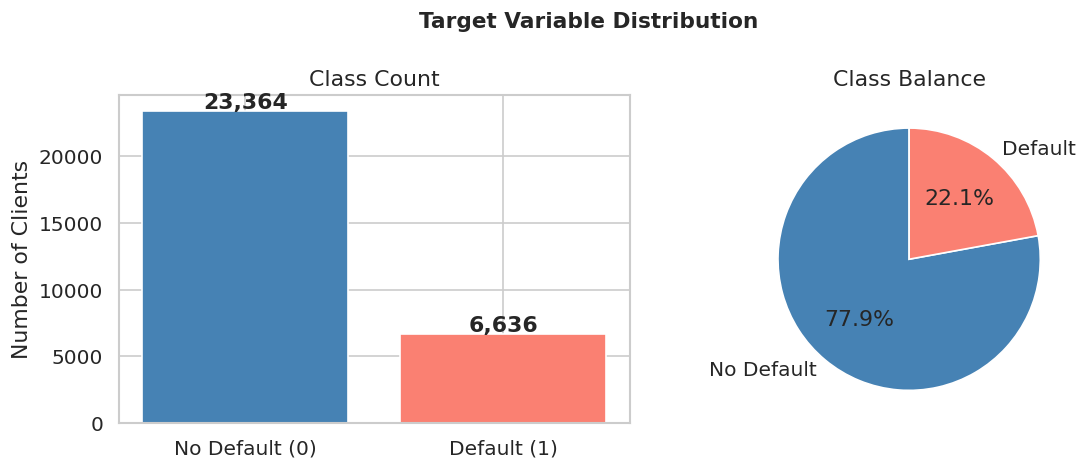

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: bar chart ---
counts = df['DEFAULT'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'],
            counts.values,
            color=['steelblue', 'salmon'],
            edgecolor='white')
axes[0].set_title('Class Count')
axes[0].set_ylabel('Number of Clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# --- Right: pie chart ---
axes[1].pie(counts.values,
            labels=['No Default', 'Default'],
            autopct='%1.1f%%',
            colors=['steelblue', 'salmon'],
            startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Categorical Feature Distributions

Inspecting EDUCATION and MARRIAGE for undocumented category codes.
According to the dataset documentation:
- EDUCATION: 1=graduate school, 2=university, 3=high school, 4=other
- MARRIAGE: 1=married, 2=single, 3=other

Any values outside these are undocumented and need to be investigated.

In [59]:
print('EDUCATION value counts:')
print(df['EDUCATION'].value_counts().sort_index())

print('\nMARRIAGE value counts:')
print(df['MARRIAGE'].value_counts().sort_index())

print('\nSEX value counts:')
print(df['SEX'].value_counts().sort_index())

EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

SEX value counts:
SEX
1    11888
2    18112
Name: count, dtype: int64


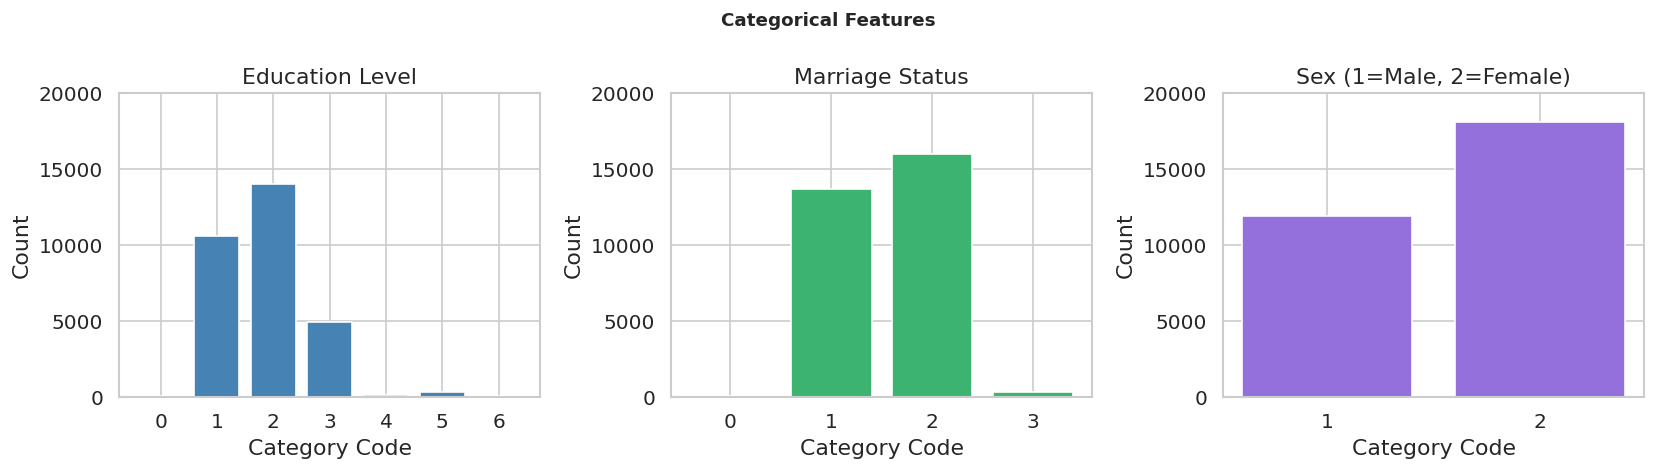

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cat_cols  = ['EDUCATION', 'MARRIAGE', 'SEX']
titles    = ['Education Level', 'Marriage Status', 'Sex (1=Male, 2=Female)']
colors    = ['steelblue', 'mediumseagreen', 'mediumpurple']

for ax, col, title, color in zip(axes, cat_cols, titles, colors):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Category Code')
    ax.set_ylabel('Count')
    ax.set_ylim(0, 20000)

plt.suptitle('Categorical Features',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Numeric Feature Distributions

Comparing distributions of numeric features between defaulters and non-defaulters.
Differences in shape or location between the two groups indicate predictive value.

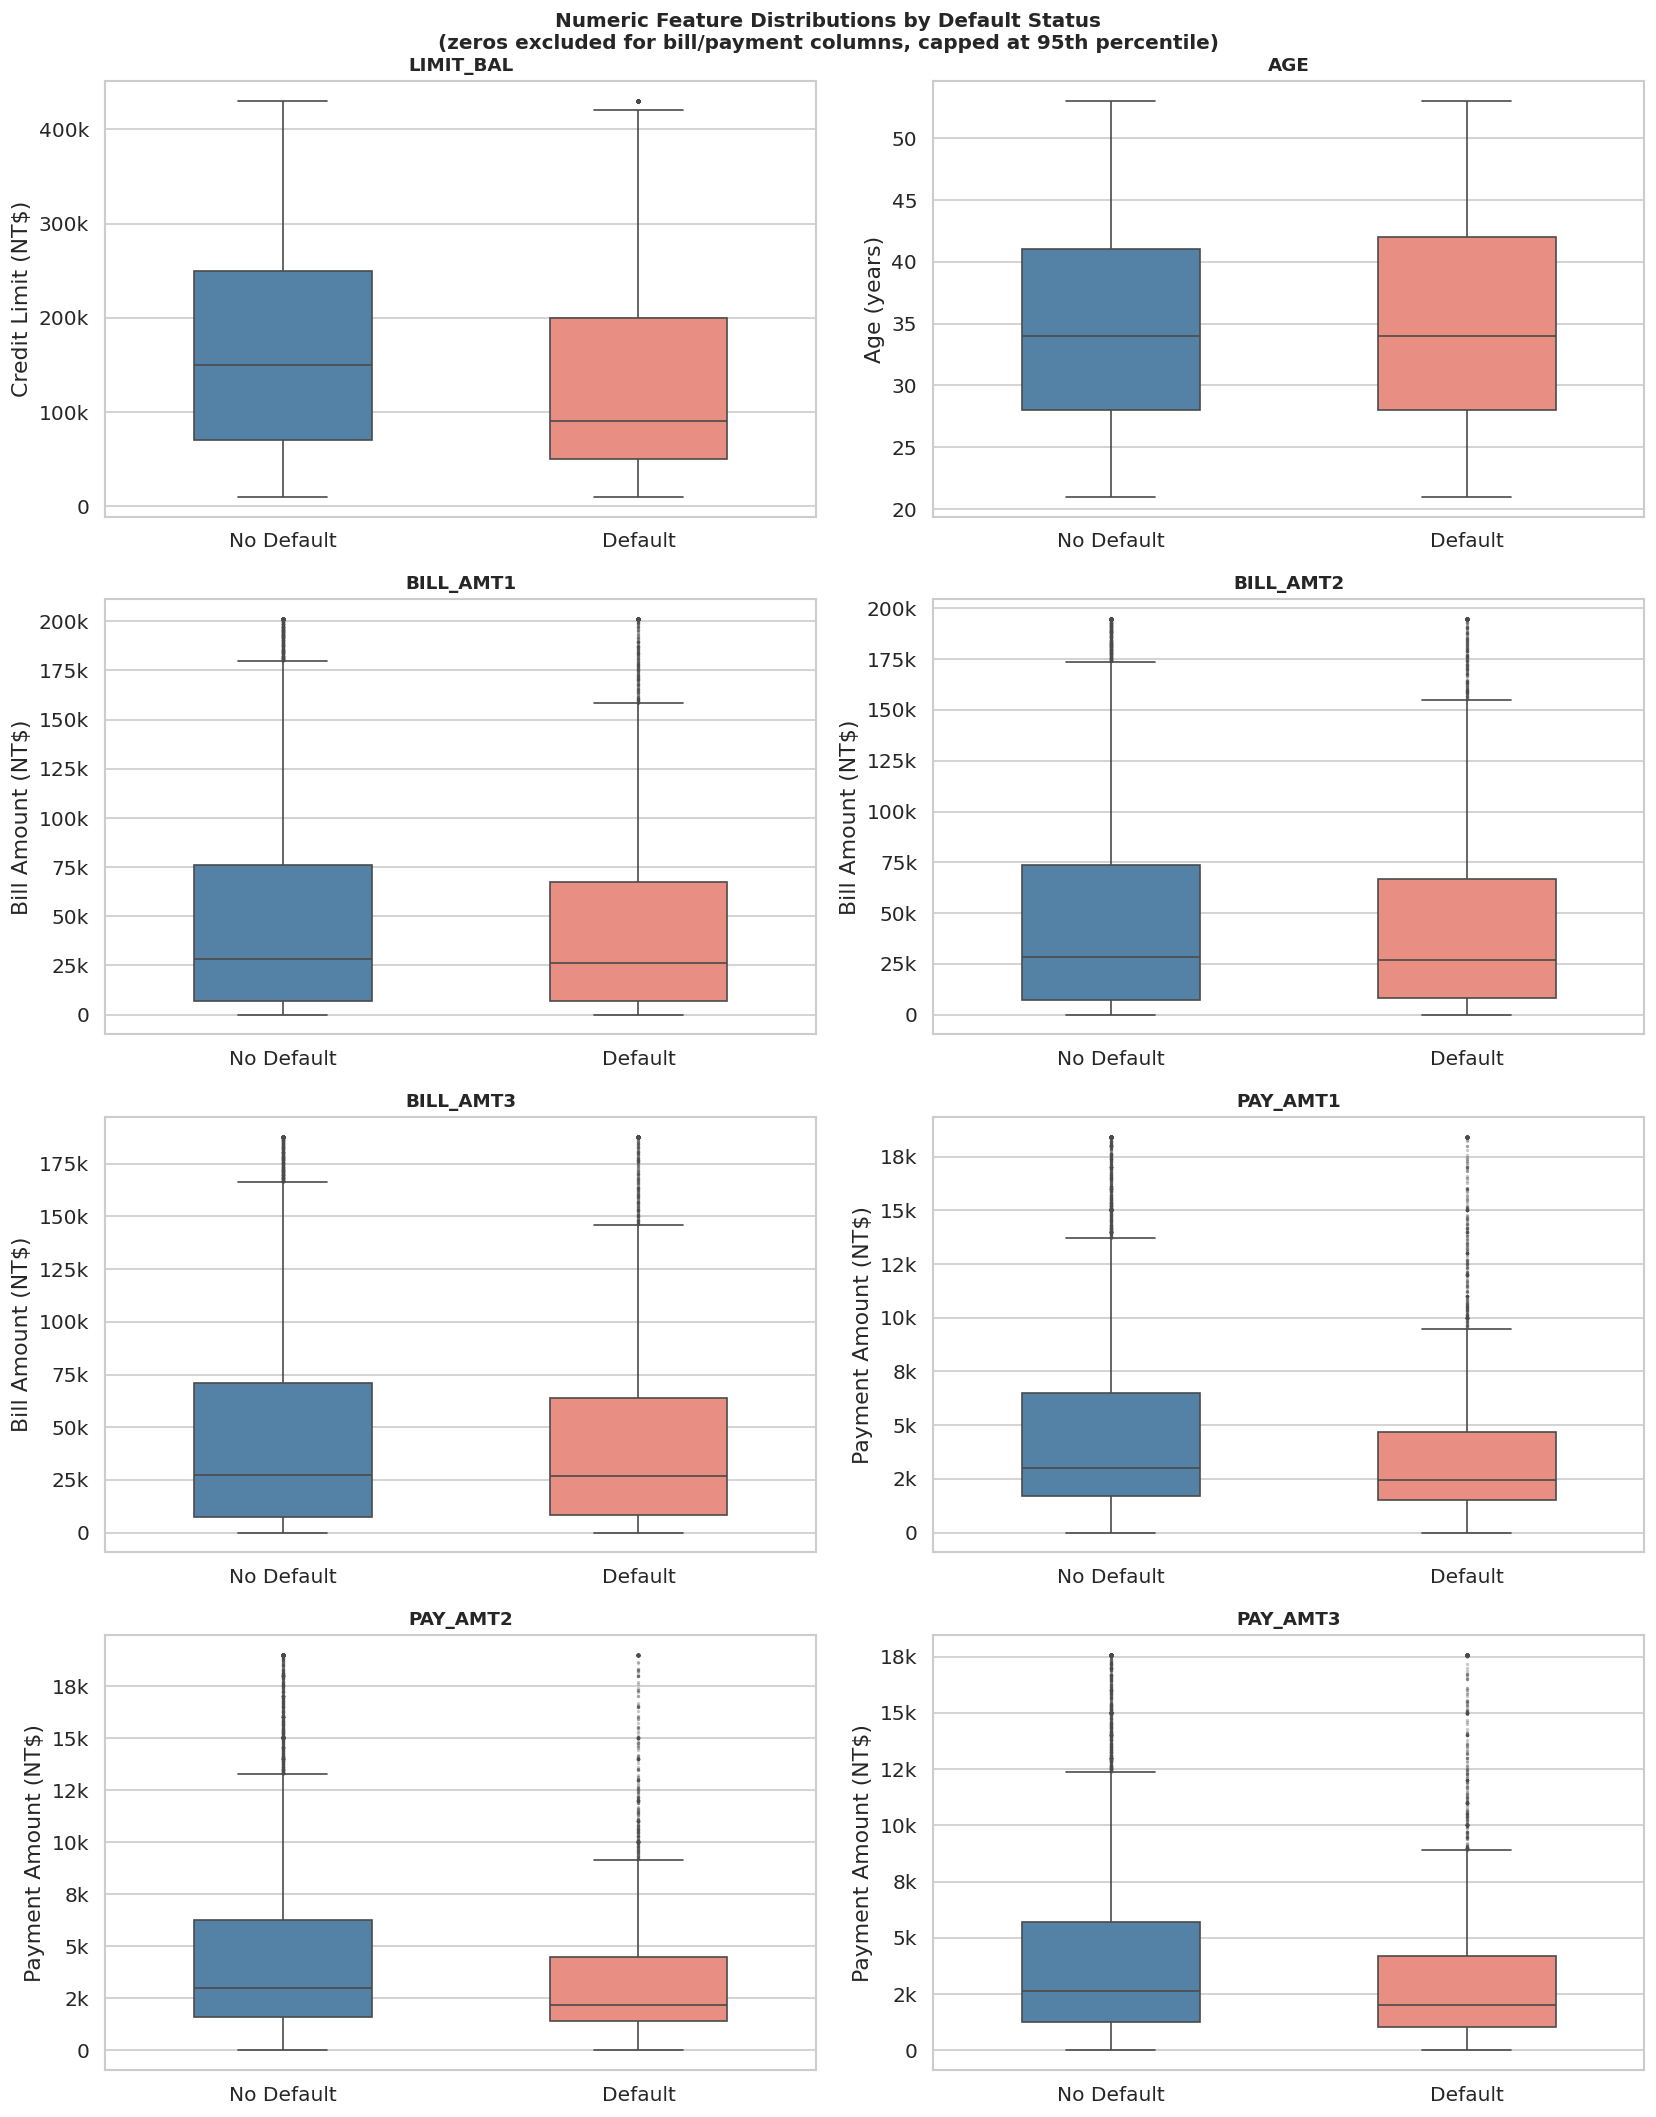

In [61]:
import seaborn as sns

numeric_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    
    cap = df[col].quantile(0.95)
    plot_df = df[[col, 'DEFAULT']].copy()
    plot_df[col] = plot_df[col].clip(upper=cap)
    
    if col.startswith('BILL_AMT') or col.startswith('PAY_AMT'):
        plot_df = plot_df[plot_df[col] > 0]
    
    plot_df['DEFAULT'] = plot_df['DEFAULT'].astype(str)
    
    sns.boxplot(data=plot_df, x='DEFAULT', y=col,
                palette={'0': 'steelblue', '1': 'salmon'},
                order=['0', '1'],
                width=0.5, ax=ax,
                flierprops=dict(marker='o', markersize=1, alpha=0.3))
    
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(['No Default', 'Default'])
   
    # Set appropriate y axis label
    if col == 'AGE':
        ax.set_ylabel('Age (years)')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    elif col == 'LIMIT_BAL':
        ax.set_ylabel('Credit Limit (NT$)')
    elif col.startswith('BILL_AMT'):
        ax.set_ylabel('Bill Amount (NT$)')
    elif col.startswith('PAY_AMT'):
        ax.set_ylabel('Payment Amount (NT$)')
    else:
        ax.set_ylabel('Value (NT$)')
    
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}')
    )

plt.suptitle('Numeric Feature Distributions by Default Status\n(zeros excluded for bill/payment columns, capped at 95th percentile)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Repayment History vs Default Rate

The PAY columns record how late a client was in paying each month.
-2 = no consumption, -1 = paid in full, 0 = minimum paid, 1 = one month late, 2 = two months late, etc.

We expect clients who pay late consistently to have a much higher default rate.
This is the most important finding in the EDA.

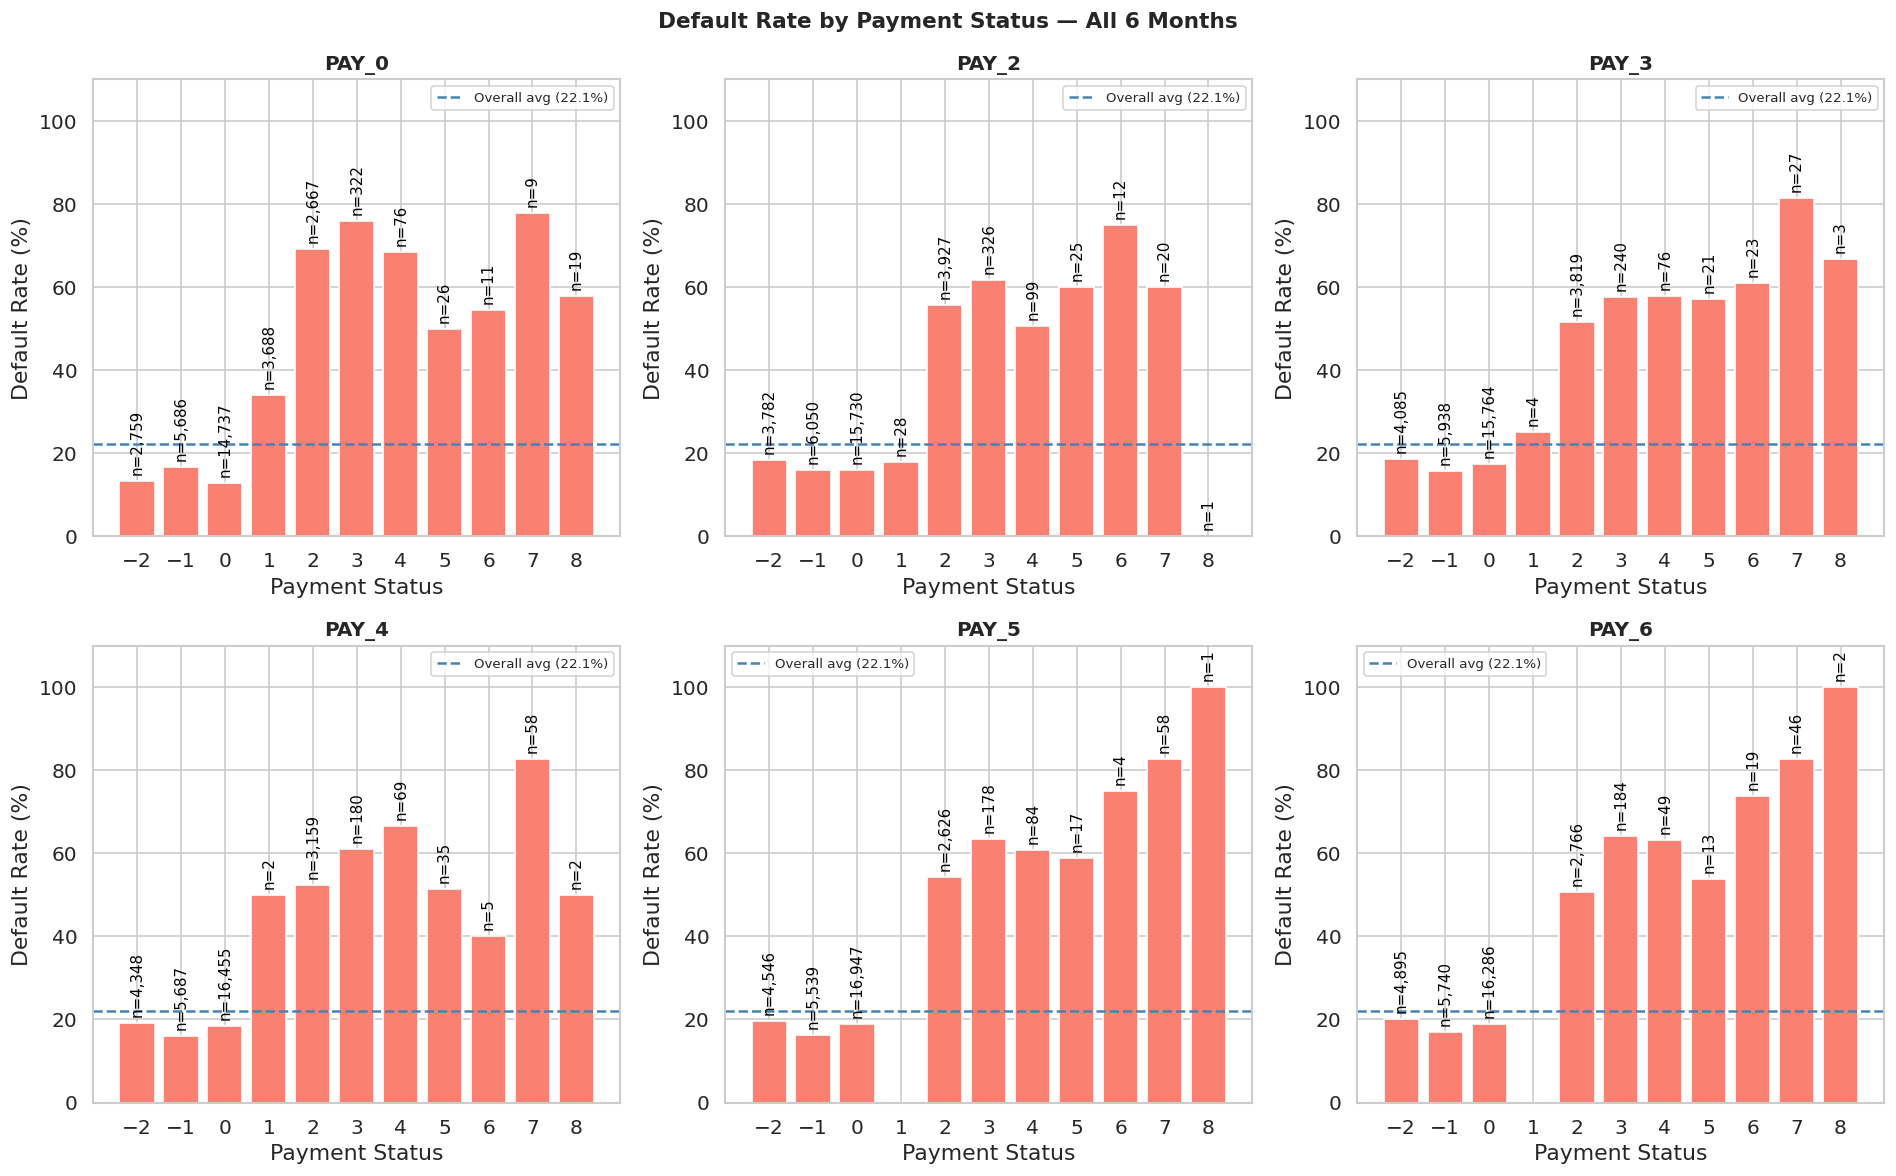

In [62]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, pay_cols):
    
    # Calculate default rate AND sample size per group
    grouped = df.groupby(col).agg(
        default_rate=('DEFAULT', 'mean'),
        count=('DEFAULT', 'count')
    ).reset_index()
    
    grouped['default_rate_pct'] = grouped['default_rate'] * 100
    
    bars = ax.bar(grouped[col], grouped['default_rate_pct'],
                  color='salmon', edgecolor='white')
    
    # Add sample size on top of each bar
    for bar, count in zip(bars, grouped['count']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'n={count:,}',
                ha='center', va='bottom',
                fontsize=9, color='black',
                rotation=90)
    
    # Dashed average line
    ax.axhline(y=22.1, color='steelblue', linestyle='--',
               linewidth=1.5, label='Overall avg (22.1%)')
    
    # Fix all y axes to same limit
    ax.set_ylim(0, 110)
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_xlabel('Payment Status')
    ax.set_ylabel('Default Rate (%)')
    ax.legend(fontsize=8)
    ax.set_xticks(range(-2, 9))
    ax.set_xlim(-3, 9)

plt.suptitle('Default Rate by Payment Status — All 6 Months',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Feature Correlation with DEFAULT

Rather than a full correlation matrix, we focus exclusively on each feature's linear correlation with the target variable DEFAULT. This gives a cleaner, more interpretable view of which features 
are most relevant for prediction. Salmon bars = positive correlation (higher value → more likely to default). Blue bars = negative correlation (higher value → less likely to default).

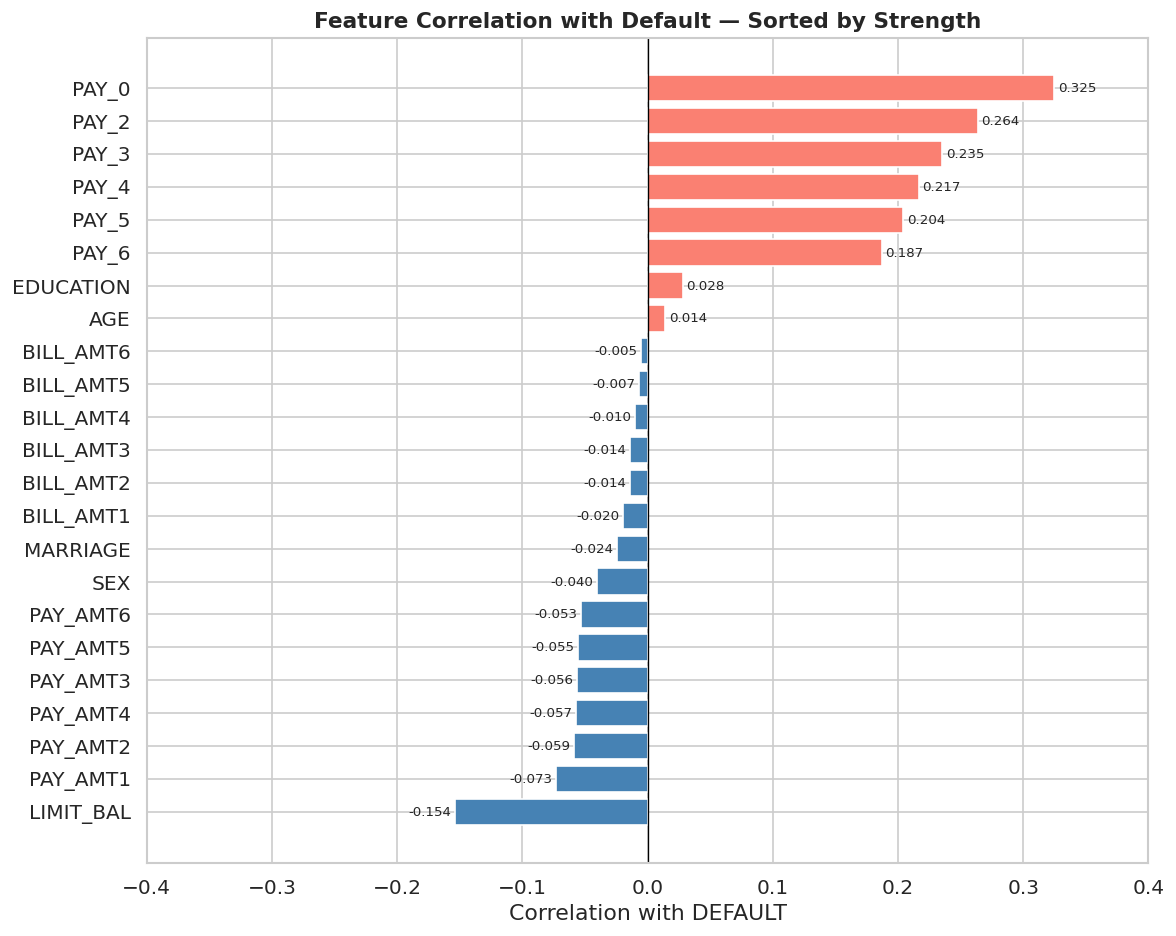

In [63]:
fig, ax = plt.subplots(figsize=(10, 8))

# Get correlation with DEFAULT only, drop DEFAULT itself, sort by absolute value
target_corr = df.corr()['DEFAULT'].drop('DEFAULT').sort_values()

colors = ['salmon' if x > 0 else 'steelblue' for x in target_corr]

ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with DEFAULT')
ax.set_title('Feature Correlation with Default — Sorted by Strength',
             fontweight='bold', fontsize=13)

# Add value labels on each bar
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            i, f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8)

ax.set_xlim(-0.4, 0.4)
plt.tight_layout()
plt.show()

Key findings:
- PAY_0 has the strongest positive correlation (0.325) — recent payment 
  delay is the single most predictive feature
- All PAY columns (PAY_0 through PAY_6) are positively correlated, 
  confirming that payment history is consistently important across all months
- LIMIT_BAL has the strongest negative correlation (-0.154) — clients 
  with higher credit limits are less likely to default
- BILL_AMT columns show weak negative correlations — consistent with the 
  finding that higher bills tend to belong to wealthier, more reliable clients
- PAY_AMT columns are negatively correlated — clients who pay more are 
  less likely to default
- SEX, MARRIAGE, EDUCATION and AGE all show near-zero correlations — 
  demographic features have minimal predictive power
- No feature exceeds 0.4 correlation — confirming there is no data leakage

### 2.6 Leakage Check

Data leakage occurs when a feature contains information that would only be
available after the target event — making the model look good in training
but fail in production.

We check two things:
1. Are all features measured BEFORE the prediction month?
2. Does any feature have a suspiciously high correlation with the target?

In [64]:
# Check 1: Timeline validation
print('=== Timeline Check ===')
print('Target: DEFAULT in October 2005')
print('PAY_0 to PAY_6: repayment status April–September 2005 ✓')
print('BILL_AMT1 to BILL_AMT6: bill statements April–September 2005 ✓')
print('PAY_AMT1 to PAY_AMT6: payments made April–September 2005 ✓')
print('LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE: static client info ✓')
print('\nAll features precede the target month — no timeline leakage.')

# Check 2: Suspiciously high correlations
print('\n=== Correlation Check ===')
target_corr = df.corr()['DEFAULT'].drop('DEFAULT').abs().sort_values(ascending=False)
print(target_corr.round(3))

threshold = 0.8
leaky = target_corr[target_corr > threshold]
if len(leaky) == 0:
    print(f'\nNo feature exceeds {threshold} correlation with target — no leakage detected.')
else:
    print(f'\nWARNING: Possible leakage in: {leaky.index.tolist()}')

=== Timeline Check ===
Target: DEFAULT in October 2005
PAY_0 to PAY_6: repayment status April–September 2005 ✓
BILL_AMT1 to BILL_AMT6: bill statements April–September 2005 ✓
PAY_AMT1 to PAY_AMT6: payments made April–September 2005 ✓
LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE: static client info ✓

All features precede the target month — no timeline leakage.

=== Correlation Check ===
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL    0.154
PAY_AMT1     0.073
PAY_AMT2     0.059
PAY_AMT4     0.057
PAY_AMT3     0.056
PAY_AMT5     0.055
PAY_AMT6     0.053
SEX          0.040
EDUCATION    0.028
MARRIAGE     0.024
BILL_AMT1    0.020
BILL_AMT2    0.014
BILL_AMT3    0.014
AGE          0.014
BILL_AMT4    0.010
BILL_AMT5    0.007
BILL_AMT6    0.005
Name: DEFAULT, dtype: float64

No feature exceeds 0.8 correlation with target — no leakage detected.


## Step 3 — Data Preparation

Based on EDA findings, we need to:
1. Clean undocumented category codes in EDUCATION and MARRIAGE
2. Engineer new features from existing ones
3. Split into train / validation / test sets
4. Scale features — fit on train only to prevent leakage

### 3.1 Clean Undocumented Category Codes

EDA revealed codes not in the original documentation:
- EDUCATION: 0, 5, 6 → merged into category 4 ('other')
- MARRIAGE: 0 → merged into category 3 ('other')

In [65]:
df_clean = df.copy()

# EDUCATION: merge undocumented codes 0, 5, 6 into 4 ('other')
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: merge undocumented code 0 into 3 ('other')
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

# Verify
print('EDUCATION values after cleaning:', sorted(df_clean['EDUCATION'].unique()))
print('MARRIAGE values after cleaning:', sorted(df_clean['MARRIAGE'].unique()))

EDUCATION values after cleaning: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values after cleaning: [np.int64(1), np.int64(2), np.int64(3)]


### 3.2 Feature Engineering

Creating three new features motivated by EDA findings:
- UTIL_RATE: how much of the credit limit is being used
- LATE_COUNT: how many months the client paid late across all 6 months
- MAX_DELAY: the worst single month delay recorded

In [66]:
# Credit utilisation rate
df_clean['UTIL_RATE'] = df_clean['BILL_AMT1'] / (df_clean['LIMIT_BAL'] + 1)

# Number of months with late payment (PAY value > 0 means late)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_clean['LATE_COUNT'] = (df_clean[pay_cols] > 0).sum(axis=1)

# Worst single month delay
df_clean['MAX_DELAY'] = df_clean[pay_cols].max(axis=1)

print('New features added:')
print(df_clean[['UTIL_RATE', 'LATE_COUNT', 'MAX_DELAY']].describe().round(3))

New features added:
       UTIL_RATE  LATE_COUNT  MAX_DELAY
count  30000.000   30000.000  30000.000
mean       0.424       0.834      0.439
std        0.411       1.554      1.345
min       -0.620       0.000     -2.000
25%        0.022       0.000      0.000
50%        0.314       0.000      0.000
75%        0.830       1.000      2.000
max        6.455       6.000      8.000


### 3.3 Train / Validation / Test Split

Splitting 60% train / 20% validation / 20% test.
Stratified to preserve the 22.1% default rate in all three splits.
The test set is held out and will not be touched until final evaluation.

In [67]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['DEFAULT'])
y = df_clean['DEFAULT']

# First cut: 80% temp / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Second cut: 75% of temp = train (60% total), 25% of temp = val (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train:      {X_train.shape[0]:,} rows | Default rate: {y_train.mean()*100:.1f}%')
print(f'Validation: {X_val.shape[0]:,} rows | Default rate: {y_val.mean()*100:.1f}%')
print(f'Test:       {X_test.shape[0]:,} rows | Default rate: {y_test.mean()*100:.1f}%')

Train:      18,000 rows | Default rate: 22.1%
Validation: 6,000 rows | Default rate: 22.1%
Test:       6,000 rows | Default rate: 22.1%


### 3.4 Feature Scaling

StandardScaler fitted on training data only.
The same scaler is then applied to validation and test — no leakage.

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Validation checks
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == len(df_clean), \
    'Row count mismatch!'
assert abs(y_train.mean() - y_test.mean()) < 0.01, \
    'Default rate differs too much between splits!'

print('Scaling complete. All validation checks passed.')

Scaling complete. All validation checks passed.


## Step 4 — Model Comparison

We train four models on the training set and evaluate on the validation set.
The test set remains untouched until final evaluation in Step 5.

Models:
- Dummy Classifier: baseline — predicts majority class always
- Logistic Regression: simple, interpretable benchmark
- Random Forest: handles non-linearity and multicollinearity
- XGBoost: modern gradient boosting, typically strong on tabular data

In [69]:
import sys
!{sys.executable} -m pip install xgboost

In [70]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

### 4.1 Train and Evaluate All Models

In [71]:
models = {
    'Dummy Classifier':    DummyClassifier(strategy='most_frequent',
                                           random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                              random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100,
                                                  random_state=RANDOM_STATE,
                                                  n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100,
                                         random_state=RANDOM_STATE,
                                         eval_metric='logloss',
                                         n_jobs=-1),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    val_proba = model.predict_proba(X_val_sc)[:, 1]
    roc = roc_auc_score(y_val, val_proba)
    pr  = average_precision_score(y_val, val_proba)
    results[name] = {'ROC-AUC': roc, 'PR-AUC': pr}
    print(f'{name:<25} ROC-AUC: {roc:.4f}  |  PR-AUC: {pr:.4f}')

results_df = pd.DataFrame(results).T

Dummy Classifier          ROC-AUC: 0.5000  |  PR-AUC: 0.2212
Logistic Regression       ROC-AUC: 0.7538  |  PR-AUC: 0.5064
Random Forest             ROC-AUC: 0.7693  |  PR-AUC: 0.5246
XGBoost                   ROC-AUC: 0.7689  |  PR-AUC: 0.5267


### 4.2 Model Comparison Chart

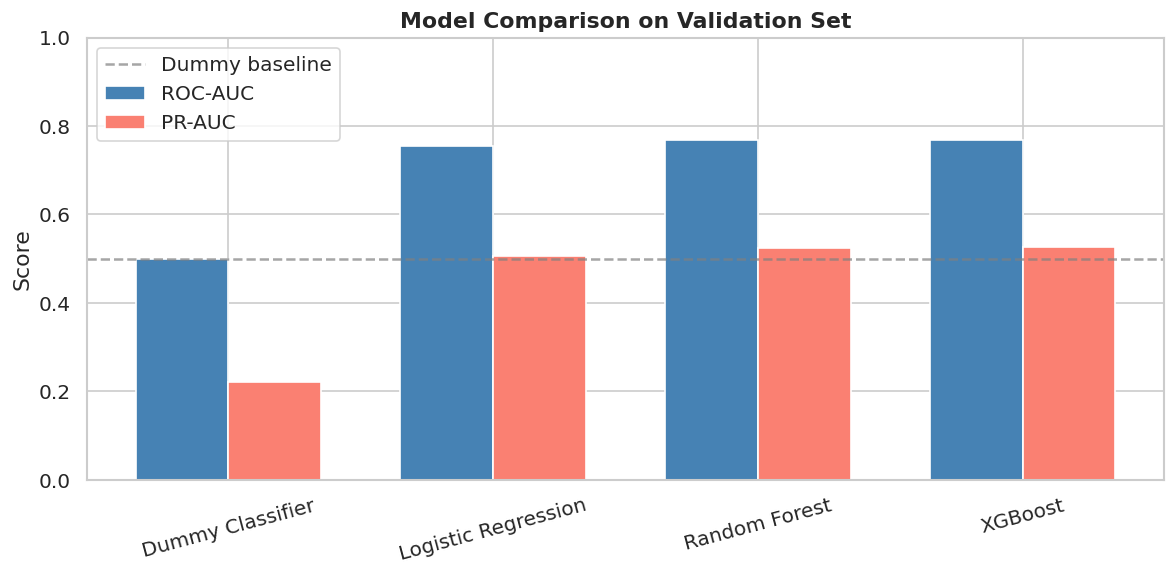


Full results table:
                     ROC-AUC  PR-AUC
Dummy Classifier      0.5000  0.2212
Logistic Regression   0.7538  0.5064
Random Forest         0.7693  0.5246
XGBoost               0.7689  0.5267


In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['ROC-AUC'], width,
       label='ROC-AUC', color='steelblue', edgecolor='white')
ax.bar(x + width/2, results_df['PR-AUC'], width,
       label='PR-AUC', color='salmon', edgecolor='white')

ax.axhline(y=results_df.loc['Dummy Classifier', 'ROC-AUC'],
           color='grey', linestyle='--', alpha=0.7, label='Dummy baseline')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Model Comparison on Validation Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nFull results table:')
print(results_df.round(4))

## Step 5 — Fine-Tuning & Evaluation

We take XGBoost forward as our best model based on Step 4 results.

This step covers:
1. Hyperparameter tuning using GridSearchCV with cross-validation
2. Threshold optimisation
3. Final evaluation on the held-out test set
4. Error analysis — confusion matrix, ROC curve, feature importance

### 5.1 Hyperparameter Tuning

Using 5-fold stratified cross-validation on the training set.
We search over key XGBoost parameters that control model complexity.

In [73]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

xgb_base = XGBClassifier(random_state=RANDOM_STATE,
                          eval_metric='logloss',
                          n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(xgb_base, param_grid,
                           scoring='roc_auc',
                           cv=cv, n_jobs=-1, verbose=1)

grid_search.fit(X_train_sc, y_train)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.7866


### 5.2 Tuned Model — Validation Performance

In [48]:
best_xgb = grid_search.best_estimator_

val_proba_tuned = best_xgb.predict_proba(X_val_sc)[:, 1]

print(f'Tuned XGBoost — Validation ROC-AUC: {roc_auc_score(y_val, val_proba_tuned):.4f}')
print(f'Tuned XGBoost — Validation PR-AUC:  {average_precision_score(y_val, val_proba_tuned):.4f}')

Tuned XGBoost — Validation ROC-AUC: 0.7841
Tuned XGBoost — Validation PR-AUC:  0.5560


### 5.3 Threshold Optimisation

The default threshold of 0.5 is not always optimal for imbalanced problems.
We search for the threshold that maximises F1 score on the validation set.
This is then applied consistently to the test set.

Best threshold by F1 on validation set: 0.32


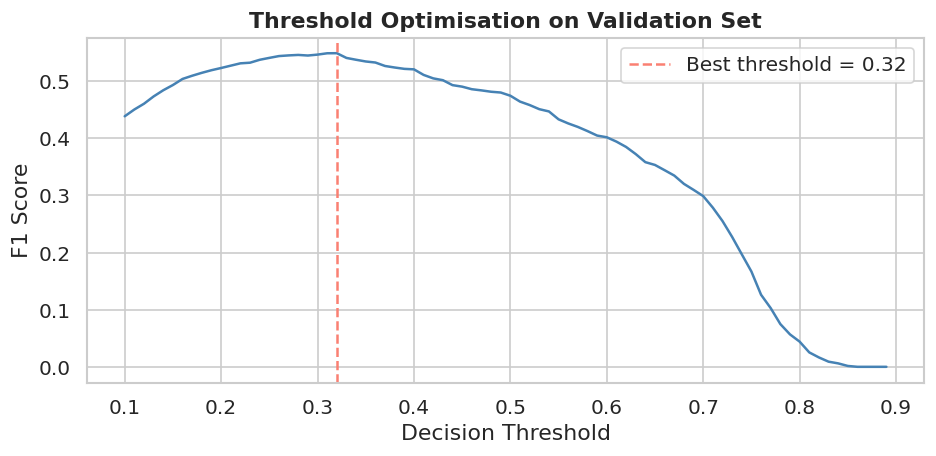

In [49]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (val_proba_tuned >= t).astype(int))
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold by F1 on validation set: {best_thresh:.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color='steelblue')
ax.axvline(best_thresh, color='salmon', linestyle='--',
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Optimisation on Validation Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Final Evaluation on Held-Out Test Set

The test set has not been used at any point during training or tuning.
This gives an unbiased estimate of real-world performance.

In [50]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay)

# Generate predictions on test set
test_proba = best_xgb.predict_proba(X_test_sc)[:, 1]
test_pred  = (test_proba >= best_thresh).astype(int)

# Metrics
test_roc = roc_auc_score(y_test, test_proba)
test_pr  = average_precision_score(y_test, test_proba)

print(f'Test ROC-AUC: {test_roc:.4f}')
print(f'Test PR-AUC:  {test_pr:.4f}')
print(f'\nClassification Report (threshold={best_thresh:.2f}):')
print(classification_report(y_test, test_pred,
                             target_names=['No Default', 'Default']))

Test ROC-AUC: 0.7810
Test PR-AUC:  0.5594

Classification Report (threshold=0.32):
              precision    recall  f1-score   support

  No Default       0.87      0.88      0.87      4673
     Default       0.55      0.52      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.80      0.80      0.80      6000



### 5.5 Confusion Matrix & ROC Curve

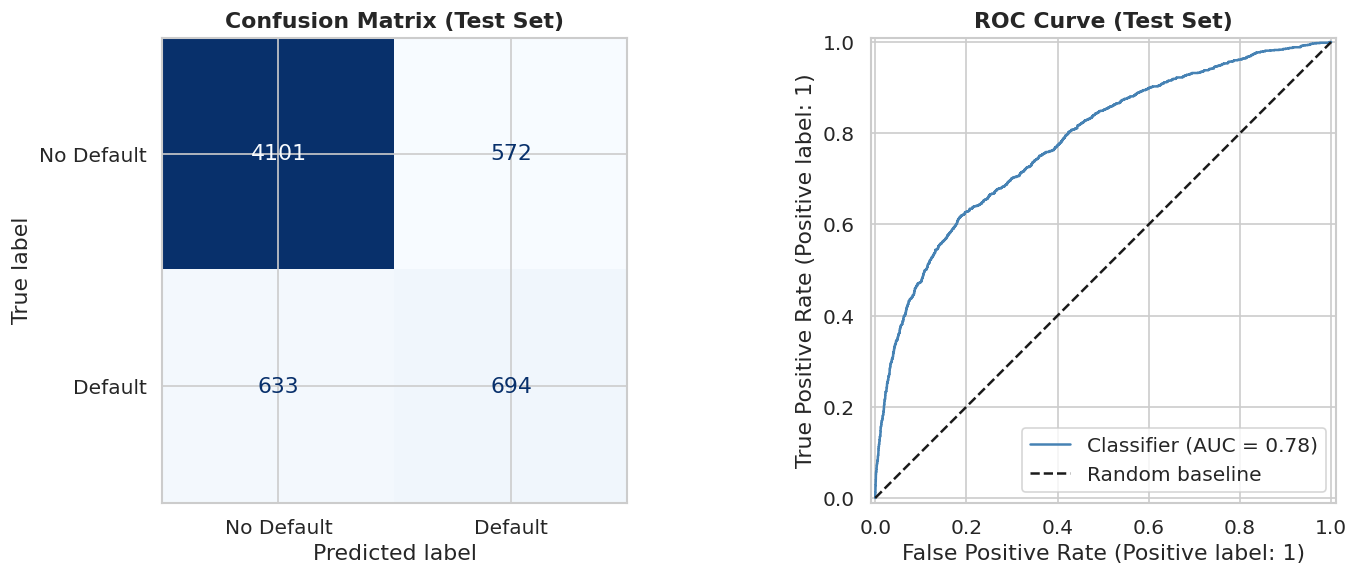

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[1],
                                  color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.6 Feature Importance

XGBoost's built-in feature importance shows which features
drove the model's predictions most strongly.
We expect PAY columns to dominate, consistent with our EDA findings.

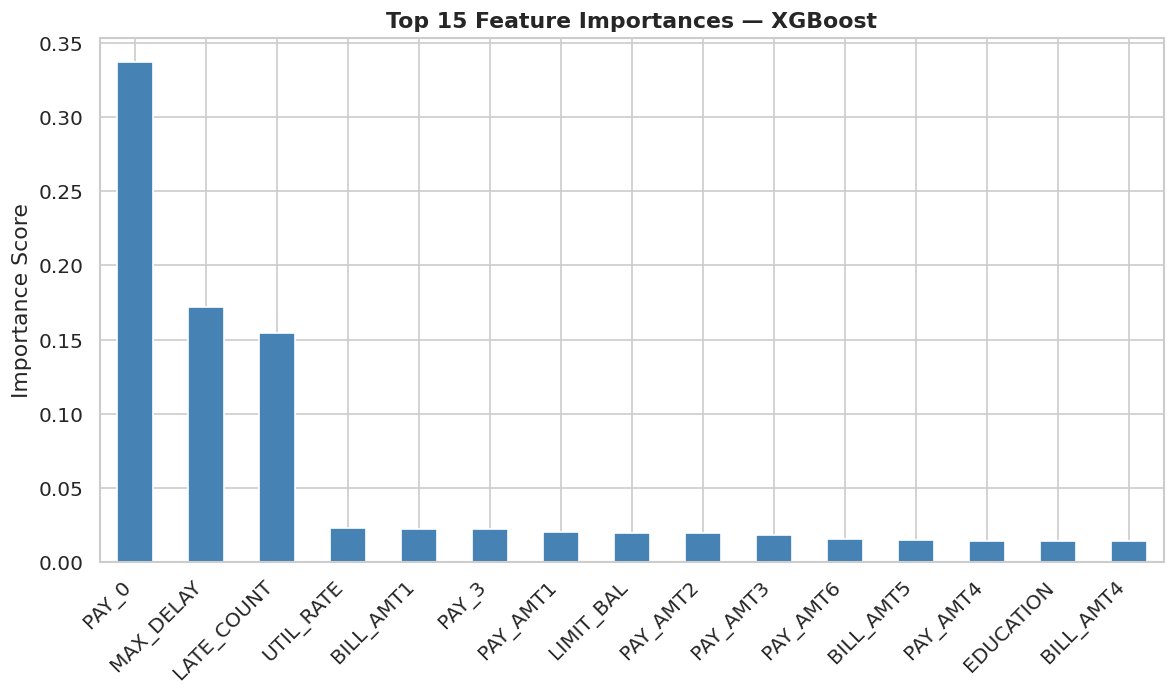


Top 10 features:
PAY_0         0.3370
MAX_DELAY     0.1720
LATE_COUNT    0.1541
UTIL_RATE     0.0225
BILL_AMT1     0.0224
PAY_3         0.0219
PAY_AMT1      0.0203
LIMIT_BAL     0.0197
PAY_AMT2      0.0196
PAY_AMT3      0.0182
dtype: float32


In [52]:
importance = pd.Series(best_xgb.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(15).plot(kind='bar', color='steelblue',
                          edgecolor='white', ax=ax)
ax.set_title('Top 15 Feature Importances — XGBoost', fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importance.head(10).round(4))

## Step 6 — Final Solution

### 6.1 Model Selection Rationale

XGBoost was selected as the final model based on the following evidence:

| Model | ROC-AUC | PR-AUC |
|-------|---------|--------|
| Dummy Classifier | 0.5000 | 0.2212 |
| Logistic Regression | 0.7538 | 0.5064 |
| Random Forest | 0.7693 | 0.5246 |
| XGBoost (untuned) | 0.7689 | 0.5267 |
| **XGBoost (tuned)** | **0.7810** | **0.5594** |

XGBoost was chosen over Random Forest because it achieved a higher PR-AUC
on the minority (default) class — the class that matters most in credit risk.
Tuning via 5-fold cross-validated GridSearch improved both metrics.

### 6.2 Model Card

| Item | Detail |
|------|--------|
| **Model type** | XGBoost binary classifier |
| **Purpose** | Predict probability of credit card default in the next month |
| **NOT intended for** | Real-time lending decisions without human review |
| **Training data** | 18,000 Taiwanese credit card clients (April–September 2005) |
| **Data source** | UCI ML Repository — Yeh & Lien (2009) |
| **Features used** | 24 features + 3 engineered (UTIL_RATE, LATE_COUNT, MAX_DELAY) |
| **Test ROC-AUC** | 0.7810 |
| **Test PR-AUC** | 0.5594 |
| **Decision threshold** | 0.32 (optimised for F1 on validation set) |
| **Key limitation** | Data is from 2005 Taiwan — may not generalise to other markets or time periods |
| **Fairness note** | SEX has near-zero feature importance — model does not discriminate by gender |

### 6.3 Limitations and Risks

- **Temporal drift:** The model was trained on 2005 data. Economic conditions change
  and the model should be retrained periodically on fresh data.

- **Class imbalance:** Despite threshold optimisation, the model still misses
  approximately 48% of actual defaulters (633 false negatives on test set).
  In high-stakes lending, this may be unacceptable without further calibration.

- **Static snapshot:** The dataset captures a single point in time. A production
  system would need a rolling retraining pipeline.

- **Feature scope:** The model has no access to external credit bureau data,
  employment status, or macroeconomic indicators, all of which could improve
  predictive power.

- **Interpretability:** While feature importance is available, XGBoost does not
  provide the per-prediction explanations required by some financial regulations
  (e.g. GDPR right to explanation). 

In [53]:
print('=== FINAL MODEL SUMMARY ===')
print(f'Model:            Tuned XGBoost')
print(f'Best params:      {grid_search.best_params_}')
print(f'Threshold:        {best_thresh:.2f}')
print(f'Test ROC-AUC:     {test_roc:.4f}')
print(f'Test PR-AUC:      {test_pr:.4f}')
print(f'Top feature:      PAY_0 (importance = 0.337)')
print(f'Engineered feats: MAX_DELAY (2nd), LATE_COUNT (3rd)')
print(f'Leakage detected: None')
print(f'Agent errors caught: XGBoost import failure — diagnosed and fixed')
print('===========================')

=== FINAL MODEL SUMMARY ===
Model:            Tuned XGBoost
Best params:      {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Threshold:        0.32
Test ROC-AUC:     0.7810
Test PR-AUC:      0.5594
Top feature:      PAY_0 (importance = 0.337)
Engineered feats: MAX_DELAY (2nd), LATE_COUNT (3rd)
Leakage detected: None
Agent errors caught: XGBoost import failure — diagnosed and fixed
